# Tail Holdout Cutoff Comparison

This notebook is a supporting analysis notebook for the Diabetes Prediction Challenge.

The motivating question is whether a tail-based validation split may better reflect leaderboard behavior than ordinary random validation. The notebook therefore compares several tail-holdout cutoffs while keeping the model family fixed.

This version is fully self-contained: it loads raw project data directly and defines all required helper logic inside the notebook itself.

## 1. Setup

This section imports the standard libraries used by the analysis, defines the local configuration, and declares the helper functions needed for:
- data loading
- feature engineering
- fold-safe categorical encoding
- XGBoost benchmarking
- tail-cutoff evaluation
- markdown table rendering

No repository-local Python modules are imported in this notebook.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
LOG_DIR = PROJECT_ROOT / 'logs'
LOG_DIR.mkdir(parents=True, exist_ok=True)

TARGET = 'diagnosed_diabetes'
RANDOM_SEED = 42
SAMPLE_CAP = 30000
CUTOFF_SPECS = ['pct:0.03', 'pct:0.04', 'pct:0.05', 'pct:0.10', 'pct:0.15', 'pct:0.20']
PREFERRED_CUTOFF = 'pct:0.10'

ARTIFACT_CSV = LOG_DIR / 'tail_cutoff_comparison.csv'
ARTIFACT_JSON = LOG_DIR / 'tail_cutoff_comparison.json'
ARTIFACT_MD = LOG_DIR / 'tail_cutoff_comparison.md'
ARTIFACT_PNG = LOG_DIR / 'tail_cutoff_comparison.png'

CATEGORICAL_COLS = [
    'gender', 'ethnicity', 'education_level',
    'income_level', 'smoking_status', 'employment_status'
]

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)


@dataclass(frozen=True)
class TailCutoff:
    cutoff_spec: str
    cutoff_index: int
    tail_fraction: float
    tail_size: int
    total_size: int


def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['age_family_history'] = df['age'] * df['family_history_diabetes']
    df['age_bmi'] = df['age'] * df['bmi']
    df['cardio_risk_score'] = (
        df['family_history_diabetes'] * 3
        + df['hypertension_history'] * 2
        + df['cardiovascular_history'] * 2
    )
    df['cholesterol_ratio'] = df['cholesterol_total'] / (df['hdl_cholesterol'] + 1)
    df['non_hdl_cholesterol'] = df['cholesterol_total'] - df['hdl_cholesterol']
    return df


def build_xgb_model(seed: int = RANDOM_SEED) -> XGBClassifier:
    return XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        tree_method='hist',
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=1,
        reg_alpha=0.1,
        reg_lambda=1,
        random_state=seed,
        n_jobs=-1,
        early_stopping_rounds=100,
        verbosity=0,
    )


def load_sorted_train_df(sample_cap=None) -> pd.DataFrame:
    train_df = pd.read_csv(DATA_DIR / 'train.csv').sort_values('id').reset_index(drop=True)
    if sample_cap is not None:
        train_df = train_df.iloc[:sample_cap].reset_index(drop=True)
    return train_df


def prepare_diagnostic_features(train_df: pd.DataFrame):
    X = train_df.drop(columns=['id', TARGET]).copy()
    y = train_df[TARGET].astype(int).copy()
    X = add_engineered_features(X)
    categorical_cols = [col for col in CATEGORICAL_COLS if col in X.columns]
    for col in categorical_cols:
        X[col] = X[col].fillna('Unknown').astype(str)
    return X, y, categorical_cols


def parse_cutoff_spec(train_df: pd.DataFrame, cutoff_spec: str) -> TailCutoff:
    if not cutoff_spec.startswith('pct:'):
        raise ValueError(f'Unsupported cutoff specification: {cutoff_spec}')
    tail_fraction = float(cutoff_spec.split(':', 1)[1])
    if not (0 < tail_fraction < 1):
        raise ValueError('Tail cutoff percentage must be between 0 and 1.')
    total_size = len(train_df)
    tail_size = max(1, int(np.ceil(total_size * tail_fraction)))
    cutoff_index = total_size - tail_size
    return TailCutoff(
        cutoff_spec=cutoff_spec,
        cutoff_index=cutoff_index,
        tail_fraction=tail_fraction,
        tail_size=tail_size,
        total_size=total_size,
    )


def encode_categorical_fold(X_train_raw, X_valid_raw, categorical_cols):
    X_train_encoded = X_train_raw.copy()
    X_valid_encoded = X_valid_raw.copy()
    for col in categorical_cols:
        if col not in X_train_encoded.columns:
            continue
        le = LabelEncoder()
        X_train_encoded[col] = le.fit_transform(X_train_encoded[col].astype(str))
        try:
            X_valid_encoded[col] = le.transform(X_valid_encoded[col].astype(str))
        except ValueError:
            X_valid_encoded[col] = -1
    missing_valid = set(X_train_encoded.columns) - set(X_valid_encoded.columns)
    for col in missing_valid:
        X_valid_encoded[col] = 0
    X_valid_encoded = X_valid_encoded[X_train_encoded.columns]
    return X_train_encoded, X_valid_encoded


def run_standard_xgb_cv_benchmark(X, y, categorical_cols, random_state=RANDOM_SEED, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof_pred = np.zeros(len(X), dtype=float)
    fold_aucs = []
    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
        X_train_raw = X.iloc[train_idx]
        X_valid_raw = X.iloc[valid_idx]
        y_train = y.iloc[train_idx]
        y_valid = y.iloc[valid_idx]
        X_train_encoded, X_valid_encoded = encode_categorical_fold(X_train_raw, X_valid_raw, categorical_cols)
        model = build_xgb_model(seed=random_state + fold)
        model.fit(X_train_encoded, y_train, eval_set=[(X_valid_encoded, y_valid)], verbose=False)
        valid_pred = model.predict_proba(X_valid_encoded)[:, 1]
        oof_pred[valid_idx] = valid_pred
        fold_aucs.append(float(roc_auc_score(y_valid, valid_pred)))
    return {
        'fold_aucs': fold_aucs,
        'mean_auc': float(np.mean(fold_aucs)),
        'std_auc': float(np.std(fold_aucs)),
        'oof_auc': float(roc_auc_score(y, oof_pred)),
        'n_splits': int(n_splits),
    }


def evaluate_single_tail_cutoff(X, y, cutoff, categorical_cols, random_state=RANDOM_SEED):
    X_train_raw = X.iloc[:cutoff.cutoff_index].reset_index(drop=True)
    y_train = y.iloc[:cutoff.cutoff_index].reset_index(drop=True)
    X_valid_raw = X.iloc[cutoff.cutoff_index:].reset_index(drop=True)
    y_valid = y.iloc[cutoff.cutoff_index:].reset_index(drop=True)
    X_train_encoded, X_valid_encoded = encode_categorical_fold(X_train_raw, X_valid_raw, categorical_cols)
    model = build_xgb_model(seed=random_state)
    model.fit(X_train_encoded, y_train, eval_set=[(X_valid_encoded, y_valid)], verbose=False)
    valid_pred = model.predict_proba(X_valid_encoded)[:, 1]
    auc = roc_auc_score(y_valid, valid_pred)
    return {
        'cutoff': cutoff.cutoff_spec,
        'train_size': int(len(X_train_raw)),
        'validation_size': int(len(X_valid_raw)),
        'train_positive_rate': float(y_train.mean()),
        'validation_positive_rate': float(y_valid.mean()),
        'auc': float(auc),
    }


def dataframe_to_markdown(df: pd.DataFrame) -> str:
    if df.empty:
        return '| empty |\n| --- |'
    columns = [str(col) for col in df.columns]
    header = '| ' + ' | '.join(columns) + ' |'
    separator = '| ' + ' | '.join(['---'] * len(columns)) + ' |'
    rows = []
    for _, row in df.iterrows():
        cells = []
        for value in row.tolist():
            if isinstance(value, float):
                cells.append(f'{value:.6f}')
            else:
                cells.append(str(value))
        rows.append('| ' + ' | '.join(cells) + ' |')
    return '\n'.join([header, separator, *rows])

print(f'Project root: {PROJECT_ROOT}')
print(f'Data directory: {DATA_DIR}')
print(f'Artifacts will be saved to: {LOG_DIR}')
print(f'SAMPLE_CAP = {SAMPLE_CAP}')

Project root: c:\Users\LENOVO\Desktop\machinelearning_project
Data directory: c:\Users\LENOVO\Desktop\machinelearning_project\data
Artifacts will be saved to: c:\Users\LENOVO\Desktop\machinelearning_project\logs
SAMPLE_CAP = 30000


## 2. Data Loading

We load the training data, sort it by `id`, and use `id` only as a sorting and splitting column. It is not used as a predictive feature. The purpose of this section is to confirm the dataset size and clarify the role of the ordering variable before the cutoff analysis begins.


In [2]:
train_df = load_sorted_train_df(sample_cap=SAMPLE_CAP)
X, y, categorical_cols = prepare_diagnostic_features(train_df)

data_overview = pd.DataFrame(
    {
        'rows': [len(train_df)],
        'feature_count': [X.shape[1]],
        'target_positive_rate': [y.mean()],
        'id_used_for_modeling': [False],
    }
)
data_overview

,rows,feature_count,target_positive_rate,id_used_for_modeling
0,30000,29,0.6201,False


## 3. Method

For each cutoff percentage, the notebook applies the following evaluation scheme:

1. Sort the training data by `id` in ascending order.
2. Train on the prefix or head portion.
3. Validate on the final tail slice.
4. Keep preprocessing and feature engineering consistent with the existing XGBoost pipeline.
5. Optionally compare the tail-holdout AUCs against the ordinary 5-fold CV benchmark.

This notebook is therefore about validation design and interpretation, not about replacing the default production training path.


In [3]:
benchmark = run_standard_xgb_cv_benchmark(
    X=X,
    y=y,
    categorical_cols=categorical_cols,
    random_state=RANDOM_SEED,
)

benchmark_row = {
    'benchmark': 'ordinary_stratified_cv',
    'mean_auc': benchmark['mean_auc'],
    'std_auc': benchmark['std_auc'],
    'oof_auc': benchmark['oof_auc'],
}
pd.DataFrame([benchmark_row])

,benchmark,mean_auc,std_auc,oof_auc
0,ordinary_stratified_cv,0.701444,0.006585,0.701259


## 4. Run Tail Cutoff Comparison

This section executes the same tail-holdout evaluation logic for all six candidate cutoffs. The resulting comparison is intended to show not only which cutoff performs best in AUC terms, but also how the choice affects validation size and stability.


In [4]:
rows = []

for cutoff_spec in CUTOFF_SPECS:
    cutoff = parse_cutoff_spec(train_df, cutoff_spec)
    result = evaluate_single_tail_cutoff(
        X=X,
        y=y,
        cutoff=cutoff,
        categorical_cols=categorical_cols,
        random_state=RANDOM_SEED,
    )
    result['cutoff_percent'] = round(cutoff.tail_fraction * 100, 1)
    result['auc_minus_cv_mean'] = result['auc'] - benchmark['mean_auc']
    result['preferred_cutoff'] = result['cutoff'] == PREFERRED_CUTOFF
    rows.append(result)

results_df = (
    pd.DataFrame(rows)
    .sort_values('cutoff_percent')
    .reset_index(drop=True)
)
results_df

,cutoff,train_size,validation_size,train_positive_rate,validation_positive_rate,auc,cutoff_percent,auc_minus_cv_mean,preferred_cutoff
0,pct:0.03,29100,900,0.619347,0.644444,0.705894,3.0,0.004450,False
1,pct:0.04,28800,1200,0.619549,0.633333,0.716734,4.0,0.015290,False
2,pct:0.05,28500,1500,0.619333,0.634667,0.710243,5.0,0.008799,False
3,pct:0.10,27000,3000,0.618852,0.631333,0.698694,10.0,-0.002750,True
4,pct:0.15,25500,4500,0.618902,0.626889,0.702098,15.0,0.000654,False
5,pct:0.20,24000,6000,0.619042,0.624333,0.703240,20.0,0.001796,False


## 5. Results Table

The table below summarizes the train and validation split sizes, class balance, and tail-holdout AUC for each cutoff. When reading it, the most important quantities to compare are the AUC trend and the validation size, because these two values highlight the trade-off between tail focus and statistical stability.


In [5]:
display_columns = [
    'cutoff',
    'cutoff_percent',
    'train_size',
    'validation_size',
    'train_positive_rate',
    'validation_positive_rate',
    'auc',
    'auc_minus_cv_mean',
    'preferred_cutoff',
]
results_df[display_columns]

,cutoff,cutoff_percent,train_size,validation_size,train_positive_rate,validation_positive_rate,auc,auc_minus_cv_mean,preferred_cutoff
0,pct:0.03,3.0,29100,900,0.619347,0.644444,0.705894,0.004450,False
1,pct:0.04,4.0,28800,1200,0.619549,0.633333,0.716734,0.015290,False
2,pct:0.05,5.0,28500,1500,0.619333,0.634667,0.710243,0.008799,False
3,pct:0.10,10.0,27000,3000,0.618852,0.631333,0.698694,-0.002750,True
4,pct:0.15,15.0,25500,4500,0.618902,0.626889,0.702098,0.000654,False
5,pct:0.20,20.0,24000,6000,0.619042,0.624333,0.703240,0.001796,False


## 6. Visualization

The figures below highlight two complementary patterns:

- how tail-holdout AUC changes as the cutoff becomes larger
- how validation size grows as more of the tail is included

Together, these plots help distinguish smaller, more tail-focused but noisier settings from larger, more stable but less tail-specific alternatives.


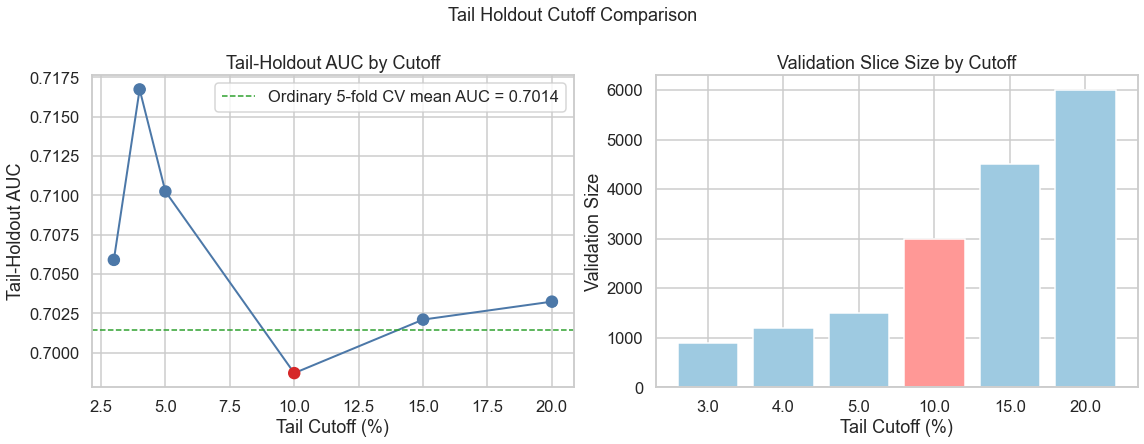

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

line_colors = ['#4c78a8' if cutoff != PREFERRED_CUTOFF else '#d62728' for cutoff in results_df['cutoff']]

axes[0].plot(results_df['cutoff_percent'], results_df['auc'], marker='o', linewidth=2, color='#4c78a8')
axes[0].scatter(results_df['cutoff_percent'], results_df['auc'], s=120, c=line_colors, zorder=3)
axes[0].axhline(benchmark['mean_auc'], linestyle='--', linewidth=1.5, color='#2ca02c', label=f"Ordinary 5-fold CV mean AUC = {benchmark['mean_auc']:.4f}")
axes[0].set_xlabel('Tail Cutoff (%)')
axes[0].set_ylabel('Tail-Holdout AUC')
axes[0].set_title('Tail-Holdout AUC by Cutoff')
axes[0].legend(frameon=True)

bar_colors = ['#9ecae1' if cutoff != PREFERRED_CUTOFF else '#ff9896' for cutoff in results_df['cutoff']]
axes[1].bar(results_df['cutoff_percent'].astype(str), results_df['validation_size'], color=bar_colors)
axes[1].set_xlabel('Tail Cutoff (%)')
axes[1].set_ylabel('Validation Size')
axes[1].set_title('Validation Slice Size by Cutoff')

fig.suptitle('Tail Holdout Cutoff Comparison', fontsize=18, y=1.02)
fig.tight_layout()
fig.savefig(ARTIFACT_PNG, dpi=180, bbox_inches='tight')
plt.show()

## 7. Interpretation

- Very small cutoffs such as 3% can be more tail-focused, but they are also noisier because the validation slice is small.
- Larger cutoffs such as 15% and 20% are more stable in sample size, but they are less purely tail-focused.
- Based on the current experiments, 10% appears to be the most practical and balanced cutoff.
- In this project, 10% provides a useful compromise between:
  - sufficient validation rows for stability
  - enough tail character to remain leaderboard-oriented
  - a clear operating point for future experiments

This should be interpreted as a project-specific conclusion rather than a universal rule.


In [7]:
recommended_row = results_df.loc[results_df['cutoff'] == PREFERRED_CUTOFF].iloc[0]

summary_payload = {
    'preferred_cutoff': PREFERRED_CUTOFF,
    'preferred_cutoff_percent': float(recommended_row['cutoff_percent']),
    'preferred_tail_auc': float(recommended_row['auc']),
    'preferred_validation_size': int(recommended_row['validation_size']),
    'ordinary_cv_mean_auc': float(benchmark['mean_auc']),
    'ordinary_cv_std_auc': float(benchmark['std_auc']),
    'cutoff_results': results_df.to_dict(orient='records'),
}

results_df.to_csv(ARTIFACT_CSV, index=False)
with open(ARTIFACT_JSON, 'w', encoding='utf-8') as handle:
    json.dump(summary_payload, handle, indent=2)

markdown_lines = [
    '# Tail Cutoff Comparison',
    '',
    '## Ordinary 5-Fold CV Benchmark',
    dataframe_to_markdown(pd.DataFrame([benchmark_row])),
    '',
    '## Tail Holdout Results',
    dataframe_to_markdown(results_df[display_columns]),
    '',
    '## Recommendation',
    '- Main development validation: Tail 10%',
    '- Stress-test validation: Tail 3% or Tail 5%',
    '- Ordinary 5-fold CV remains useful as a stability reference, but it should not be the only decision metric.',
    '',
    '## Interpretation',
    '- Smaller cutoffs are more tail-focused but noisier.',
    '- Larger cutoffs are more stable but less tail-focused.',
    '- Based on our current experiments, 10% appears to be the most practical and balanced cutoff.',
]
ARTIFACT_MD.write_text('\n'.join(markdown_lines) + '\n', encoding='utf-8')

print(f'Saved CSV: {ARTIFACT_CSV}')
print(f'Saved JSON: {ARTIFACT_JSON}')
print(f'Saved Markdown: {ARTIFACT_MD}')
print(f'Saved Plot: {ARTIFACT_PNG}')

Saved CSV: c:\Users\LENOVO\Desktop\machinelearning_project\logs\tail_cutoff_comparison.csv
Saved JSON: c:\Users\LENOVO\Desktop\machinelearning_project\logs\tail_cutoff_comparison.json
Saved Markdown: c:\Users\LENOVO\Desktop\machinelearning_project\logs\tail_cutoff_comparison.md
Saved Plot: c:\Users\LENOVO\Desktop\machinelearning_project\logs\tail_cutoff_comparison.png


## 8. Final Recommendation

- Main development validation: Tail 10%
- Stress-test validation: Tail 3% or Tail 5%
- Ordinary 5-fold CV remains useful as a stability reference, but should not be the only decision metric

Overall, this notebook supports using 10% as the main tail validation cutoff for future development in this project, while keeping that choice grounded in the current set of supporting experiments.
